In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("/star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [10]:
X = df.drop("class", axis=1)
y = df["class"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (100000, 17)
Dimensiones de y: (100000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (80000, 17)
Test: (20000, 17)


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo
rf = RandomForestClassifier(random_state=42)

# Lo entrenamos con los datos de entrenamiento
rf.fit(X_train, y_train)

# Obtenemos importancia de variables
importancias = pd.Series(rf.feature_importances_, index=X.columns)

# Ordenamos de mayor a menor
importancias = importancias.sort_values(ascending=False)

importancias

,0
redshift,0.600549
z,0.076094
g,0.066284
i,0.061825
u,0.054198
spec_obj_ID,0.031086
r,0.026751
plate,0.025989
MJD,0.017389
delta,0.008258


In [13]:
# Seleccionamos las variables más importantes
features_seleccionadas = ["redshift", "z", "g", "i", "u", "r"]

X_reducido = X[features_seleccionadas]

print("Nueva dimensión de X:", X_reducido.shape)

Nueva dimensión de X: (100000, 6)


In [14]:
X_train_red, X_test_red, y_train, y_test = train_test_split(
    X_reducido, y,
    test_size=0.2,
    random_state=42
)

print("Train reducido:", X_train_red.shape)
print("Test reducido:", X_test_red.shape)

Train reducido: (80000, 6)
Test reducido: (20000, 6)


In [15]:
modelo_final = RandomForestClassifier(random_state=42)

modelo_final.fit(X_train_red, y_train)

RandomForestClassifier(random_state=42)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

In [19]:
y_pred = modelo_final.predict(X_test_red)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.97845

Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11860
         QSO       0.97      0.92      0.94      3797
        STAR       1.00      1.00      1.00      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



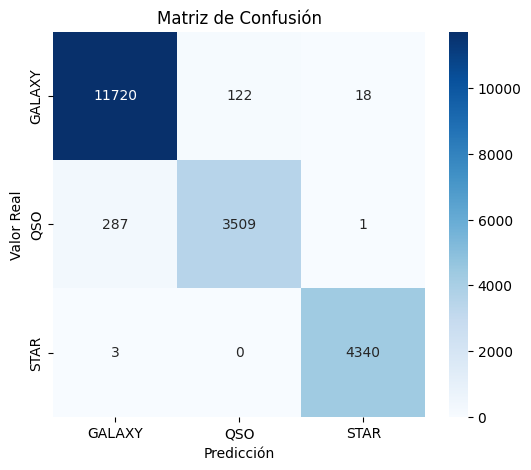

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=modelo_final.classes_,
            yticklabels=modelo_final.classes_)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

En este proyecto se trabajó con un dataset de objetos astronómicos con el objetivo de clasificarlos en GALAXY (galaxias), QSO y STAR (estrellas).

En primer lugar, se aplicó un método de selección de variables utilizando Random Forest para identificar cuáles tenían mayor importancia en la clasificación. A partir de ese análisis se observó que el redshift y las magnitudes fotométricas (u, g, r, i, z) eran las variables más relevantes, por lo que se decidió reducir la dimensionalidad del conjunto de datos y entrenar el modelo únicamente con esas características.

Posteriormente, se entrenó un modelo de clasificación Random Forest con las variables seleccionadas. Los resultados obtenidos alcanzaron una precisión global del 97,8%. La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los objetos. Los errores se presentan principalmente entre QSO y galaxias, lo cual resulta razonable debido a la similitud de sus propiedades observacionales.

En conclusión, el modelo desarrollado demuestra un rendimiento sólido y consistente. Además, la reducción de variables permitió simplificar el dataset sin afectar de manera significativa la capacidad predictiva del algoritmo.